# Розвідковий аналіз та попередня обробка даних  

Типовий процес роботи з даними в задачах аналітики та машинного навчання зазвичай виглядає так:  
- Завантаження та підготовка даних  
- Розвідковий аналіз даних (Exploratory Data Analysis, EDA)  
- Попередня обробка даних (Data preprocessing)  
- Побудова та навчання моделей машинного навчання  

**Розвідковий аналіз даних (EDA)** — це аналіз основних властивостей даних, пошук у них загальних закономірностей, розподілів і аномалій, а також формування початкового уявлення про структуру набору даних. Часто такий аналіз виконується із використанням методів статистики та інструментів візуалізації.  

Розвідковий аналіз даних може використовуватися з різною метою. Наприклад:  
- EDA допомагає дослідити структуру набору даних, виявити пропущені значення, аномалії, викиди та інші проблеми якості даних.
- Результати EDA можуть використовуватися для представлення та пояснення результатів аналізу, тобто для так званої розповіді на основі даних (data storytelling).  

Таким чином, розвідковий аналіз дозволяє краще зрозуміти структуру та особливості даних перед їх подальшою обробкою та використанням у моделях машинного навчання.

In [1]:
#  імпортуємо необхідні бібліотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_context("paper")
sns.set_palette('Dark2')

In [2]:
# графіки вбудовуються в блокнот 
%matplotlib inline

In [3]:
# відключити попередження Anaconda
import warnings
warnings.simplefilter('ignore')

In [4]:
# встановимо, що в цислах типу float виводити 2 знаки після роздільника
pd.options.display.float_format = '{:.2f}'.format

In [5]:
# Зчитуємо в датафрейм data файл з початковими даними
data = pd.read_csv('students_survey.csv')
data.head(5)

,Age,Grade_level,Study_hours_per_week,Preferred_study_method,Absent_days,Math_test_score,Extracurricular_participation,Preferred_language,Satisfaction_level,Future_plans
0,24.00,Junior,20.00,Group-study,11,93.85,Yes,C++,95.79,Undecided
1,20.00,Sophomore,31.00,Practical,7,54.99,Yes,Java,90.09,Freelancing
2,22.00,Junior,8.00,Lecture,4,67.82,Yes,C++,96.21,Undecided
3,23.00,Senior,24.00,Lecture,13,54.81,No,Java,76.23,Employment
4,22.00,Senior,28.00,Lecture,11,67.19,Yes,Java,92.51,Higher education


Цей набір даних представляє собою інформацію, зібрану в рамках опитування студентів технічних спеціальностей. Нижче наведено опис кожного стовпця:  
- Age - Вік студента на момент збору даних.  
- Grade_level - Рік навчання студента на освітній програмі. Це категоріальне значення, яке може приймати такі значення:  
Freshman (перший курс),  
Sophomore (другий курс),  
Junior (третій курс),  
Senior (четвертий курс).  
- Study_hours_per_week - Кількість годин, витрачених студентом на навчання протягом тижня. Це кількісне значення з можливими значеннями від 5 до 40 годин.  
- Preferred_study_method - Обраний студентом метод навчання, може приймати такі варіанти:  
Lecture (лекції),  
Practical (практичні заняття),  
Self-study (самостійне навчання),  
Group-study (групове навчання).  
- Absent_days - Кількість днів, протягом яких студент був відсутній на заняттях поточного семестру. Це кількісне значення, що може варіюватися від 0 до 15 днів.  
- Math_test_score - Середній бал студента з математичних предметів. Це кількісне значення, яке варіюється від 50 до 100 балів.  
- Extracurricular_participation - Участь студента в позанавчальних активностях. Це категоріальне значення з можливими варіантами "Yes" (так) або "No" (ні).
-Preferred_language - Обрана студентом мова програмування для виконання проектних робіт. Можливі варіанти:  
Python,  
C++,  
Java,
R.  
- Satisfaction_level - Рівень задоволеності студентом навчальними приміщеннями, виражений у відсотках. Це кількісне значення в діапазоні від 50% до 100%.  
- Future_plans - Плани студента після закінчення навчання, може містити такі варіанти:  
Higher education (продовження навчання),  
Employment (працевлаштування),  
Freelancing (фріланс),  
Undecided (не визначився).

---  


### Розвідковий аналіз даних  
  
**З чого складається набір даних?**  
Першим кроком розвідкового аналізу є ознайомлення зі структурою набору даних. Для швидкого перегляду структури таблиці, назв змінних і їх типів використаємо метод `info()`.

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            1150 non-null   float64
 1   Grade_level                    1150 non-null   object 
 2   Study_hours_per_week           1150 non-null   float64
 3   Preferred_study_method         1200 non-null   object 
 4   Absent_days                    1200 non-null   int64  
 5   Math_test_score                1200 non-null   float64
 6   Extracurricular_participation  1200 non-null   object 
 7   Preferred_language             1150 non-null   object 
 8   Satisfaction_level             1200 non-null   float64
 9   Future_plans                   1200 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 93.9+ KB


1. У деяких змінних (`Age`, `Grade_level`, `Study_hours_per_week`, `Preferred_language`) кількість значень менша за загальну кількість записів, що свідчить про наявність пропущених даних.  
2. Частина змінних має тип `object`, тобто містить текстові категоріальні значення. У разі використання алгоритмів машинного навчання такі змінні потребуватимуть перетворення у числовий формат.  

**Які основні характеристики мають числові показники?**  
На цьому етапі аналізуємо числові змінні, щоб зрозуміти їх типові значення, діапазон та розкид даних. Це дозволяє побачити середні значення, мінімальні та максимальні показники, а також зробити перші припущення про можливі аномалії або викиди в даних.  
Найшвидше це зробити за допомогою методу ``describe()``  

In [7]:
data.describe()

,Age,Study_hours_per_week,Absent_days,Math_test_score,Satisfaction_level
count,1150.00,1150.00,1200.00,1200.00,1200.00
mean,22.15,21.77,7.17,74.79,74.84
std,10.78,10.04,4.31,14.45,14.55
min,18.00,5.00,0.00,50.04,50.00
25%,20.00,13.00,3.00,62.20,62.42
50%,22.00,21.00,7.00,74.49,74.54
75%,23.00,30.00,11.00,87.19,87.77
max,210.00,39.00,14.00,99.83,99.98


1. Кількість значень у змінних `Age` та `Study_hours_per_week` менша за загальну кількість записів, що свідчить про наявність пропущених значень.  
2. У змінній `Age` максимальне значення дорівнює 210, що є нереалістичним і вказує на можливий викид або помилку в даних.  
3. Інші числові змінні мають значення в очікуваних діапазонах (наприклад, `Math_test_score` від ~50 до ~100).  
4. Таким чином, під час подальшої обробки даних необхідно:  
   - опрацювати пропущені значення;  
   - перевірити та обробити аномальні значення.  

**Які категорії представлені у даних і які з них найпоширеніші?**   

Для категоріальних змінних важливо зрозуміти, які значення (категорії) присутні у даних та як часто вони зустрічаються. Це дозволяє побачити структуру вибірки, визначити найпоширеніші категорії та помітити можливі незбалансовані розподіли.  

In [8]:
cat_cols = data.select_dtypes(include='object').columns # обираю категоріальні змінні

for col in cat_cols:
    print(f'{data[col].value_counts()} \n')

Grade_level
Sophomore    304
Junior       291
Senior       287
Freshman     268
Name: count, dtype: int64 

Preferred_study_method
Lecture        303
Practical      302
Group-study    299
Self-study     296
Name: count, dtype: int64 

Extracurricular_participation
Yes    616
No     584
Name: count, dtype: int64 

Preferred_language
Java      468
R         234
C++       231
Python    217
Name: count, dtype: int64 

Future_plans
Undecided           304
Employment          302
Freelancing         301
Higher education    293
Name: count, dtype: int64 



1. Усі категоріальні змінні містять обмежену кількість чітко визначених категорій, що свідчить про відсутність явних помилок у написанні значень.  
2. Розподіл значень у категоріальних змінних є відносно збалансованим, жодна категорія не домінує над іншими.  
3. Таким чином, у категоріальних змінних не виявлено явних проблем якості даних, однак для подальшого використання в алгоритмах машинного навчання ці змінні потребуватимуть кодування у числовий формат.  

**Чи відрізняються показники між різними групами студентів?**  

Під час розвідкового аналізу бувають випадки, коли важливо перевірити, чи змінюються числові показники залежно від певних категорій. Наприклад, чи відрізняються результати тесту з математики між студентами різних курсів або чи впливає обраний метод навчання на успішність. Для такого аналізу використовують групування даних та обчислення узагальнених статистик для кожної групи.  

**Метод ``.groupby()``** використовується для групування даних по категоріях і застосування функції до категорій.  
**``df.groupby(categorical_column)[numeric_column].function()``**  
У якості function() найчастіше використовують:  
мінімальне min()  
максимальне max()  
середнє mean()  
мода mode()  
медіана median()  
сума sum()  
кількість count()

In [9]:
# Медіанні оцінки студентів в залежності від обраного метода навчання
data.groupby('Preferred_study_method')[['Math_test_score']].median()

,Math_test_score
Preferred_study_method,
Group-study,74.15
Lecture,74.49
Practical,75.70
Self-study,73.83


In [10]:
#Можна одразу порахувати кілька статистик для кожної групи за допомогою agg().
data.groupby('Preferred_study_method')['Math_test_score'].agg(
    median='median',
    min='min',
    max='max',
)

,median,min,max
Preferred_study_method,,,
Group-study,74.15,50.04,99.73
Lecture,74.49,50.18,99.66
Practical,75.70,50.11,99.41
Self-study,73.83,50.06,99.83


1. Значення медіани результатів тесту з математики є близькими для всіх груп студентів, що свідчить про відсутність значних відмінностей між групами.
2. Мінімальні та максимальні значення балів у всіх групах знаходяться приблизно в одному діапазоні (близько 50–100), що відповідає очікуваному діапазону оцінювання.

**Чи є в наборі даних пропущені значення?**  

У реальних наборах даних часто зустрічаються пропущені значення. Вони можуть виникати через помилки збору даних, відсутність відповіді респондента або технічні проблеми під час обробки інформації.  
Окрім методу ``info()`` кількість пропусків також можна отримати за допомогою ``isnull().sum()``

In [11]:
data.isnull().sum()

Age                              50
Grade_level                      50
Study_hours_per_week             50
Preferred_study_method            0
Absent_days                       0
Math_test_score                   0
Extracurricular_participation     0
Preferred_language               50
Satisfaction_level                0
Future_plans                      0
dtype: int64

**Чи існує взаємозв’язок між числовими показниками?**  

На завершальному етапі розвідкового аналізу можна дослідити, чи пов’язані між собою числові змінні набору даних. Для цього використовують кореляційний аналіз, який дозволяє оцінити силу та напрямок зв’язку між показниками. Це може допомогти виявити змінні, які впливають одна на одну, або знайти потенційно важливі фактори для подальшого аналізу.

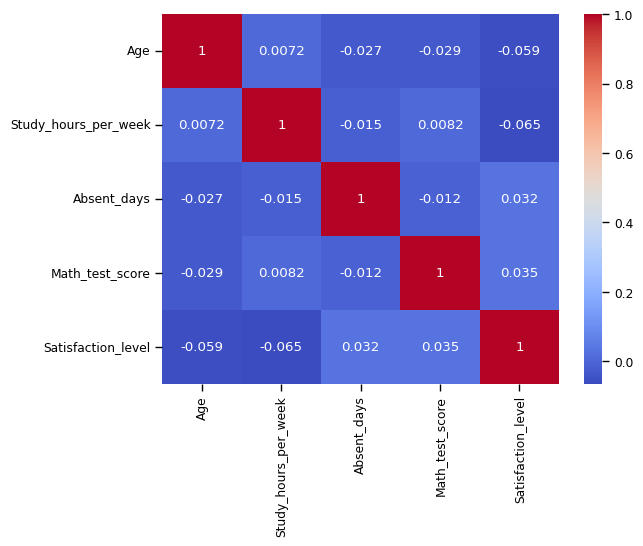

In [12]:
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

1. Значення коефіцієнтів кореляції між числовими змінними є близькими до нуля, що свідчить про відсутність сильних лінійних зв’язків між показниками.  
2. Жодна пара змінних не має високої кореляції, тому в даних не спостерігається проблеми мультиколінеарності.

   ---   

**Підсумкові висновки розвідкового аналізу даних** 

1. У наборі даних виявлено пропущені значення у деяких змінних.  
2. У змінній `Age` виявлено нереалістичне максимальне значення, що свідчить про наявність аномального значення або помилки у даних.  
3. Частина змінних має категоріальний тип (текстові значення), тому для використання у моделях машинного навчання їх необхідно буде перекодувати у числовий формат.  
4. Сильних кореляцій між числовими змінними не виявлено, тому явної проблеми мультиколінеарності в даних немає.

### 2. Попередня обробка даних  

Після розвідкового аналізу даних наступним етапом роботи є їх попередня обробка. На цьому етапі усувають проблеми якості даних, які були виявлені під час EDA, зокрема пропущені значення, аномальні спостереження або некоректні типи змінних. Метою цього етапу є підготовка даних до подальшого аналізу та використання в моделях машинного навчання.

#### 2.1. Виявлення та виключення викидів з даних  
Виявлення та видалення викидів є важливим кроком у попередній обробці даних для забезпечення достовірності та надійності вашого аналізу.   
**Ось загальна стратегія для виявлення та видалення викидів:**
- Візуалізуйте дані або виведіть основну описову статистику для змінних: Перед виявленням викидів часто корисно візуалізувати ваші дані за допомогою гістограм, box plots, scatter plots або інших відповідних графіків. Візуальний огляд часто може виявити потенційні викиди.  
- Визначте критерії для ідентифікації викидів у вашому наборі даних. Загальні методи включають:  
а) Використання z-оцінок: Значення, що відхиляються за певною кількістю стандартних відхилень від середнього, вважаються викидами.    
б) Міжквартильний розмах (IQR): Значення, які випадають нижче за Q1 - 1.5 * IQR або вище за Q3 + 1.5 * IQR, вважаються викидами.  
в) Знання предметної області: Іноді викиди можуть бути виявлені на основі досвіду, професійних знань або бізнес-правил.    
  
На прикладі змінної Age розглянемо виключення викидів, нетипових та помилково введених даних

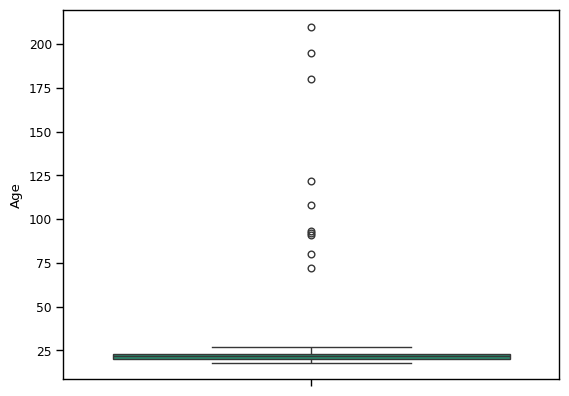

In [13]:
# для діагностики викидів та нетипових спостережень найкраще підходить коробчаста діаграма
sns.boxplot(data['Age']);

In [14]:
# залишаю студентів, вік яких не перевищує 70 років
data = data[data['Age'] <= 70]

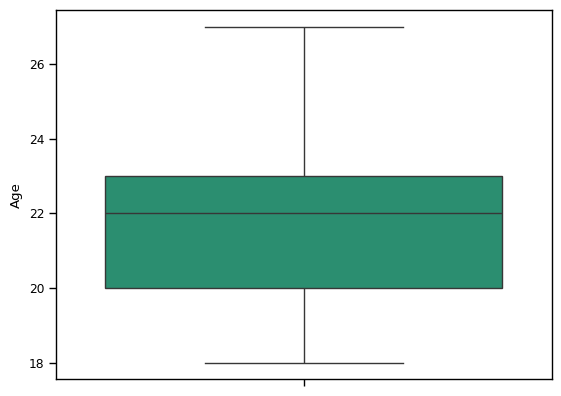

In [15]:
#перевірю розподіл віку студентів після опрацювання викидів
sns.boxplot(data['Age']);

#### 2.2  Видалення та заповнення пропусків в даних  
З попередніх лекцій:  
**df.dropna()** - видалити рядки, в яких є пропуски  
**df.fillna()** - заповнити рядки, в яких є пропуски вказаною інформацією  
  
**Деякі базові стратегії заповнення пропущених значень:**  
- Медіана або середнє значення: Замініть пропущені значення середнім або медіанним значенням стовпця.  
- Мода: Заповнення пропущених значень найчастішим значенням у стовпці.  
- Лінійна інтерполяція: Оцінка пропущених значень на основі відомих значень в товпчику.  
- Прогностичні моделі: Використання моделей машинного навчання для прогнозування пропущених значень на основі інших ознак у наборі даних.

<span style="color:red"> **!!!**</span> Кожна стратегія має свої переваги та недоліки, і вибір методу повинен бути спрямований на особливості набору даних та конкретні вимоги аналізу або моделювання. Крім того, важливо врахувати потенційний вплив заповнення на цілісність та вірогідність даних.  
<span style="color:red">**!!!**</span> Немає однозначної відповіді на питання про те, який відсоток пропущених значень є прийнятним для заповнення, оскільки це залежить від конкретного дослідження та його вимог. Ви можете провести експерименти з різними відсотками заповнення та оцінити, як це впливає на результати вашого аналізу або моделі.

Отже, є пропуски в:  
- стовпчиках з кількісними даними: **Age, Study_hours_per_week**  
- стовпчиках із категоріальними даними: **Grade_level, Preferred_language**   

<span style="color:red"> **Автоматизація процесу заповнення пропусків**</span>  
Якщо в наборі даних багато стовпчиків з пропусками, то можна автоматизувати процес їх заповнення без залучення методів fillna() та dropna().  
Imputer (в бібліотеці scikit-learn реалізований як SimpleImputer) - це інструмент для автоматизованого заповнення пропусків у даних (NaN). Він дозволяє задати правило, за яким усі пропуски в стовпці будуть замінені одним значенням. Це спрощує обробку даних та зменшує втрату інформації.  
У загальному вигляді синтаксис можна подати так:  

```python
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="...", fill_value=...)
df[cols] = imputer.fit_transform(df[cols])
```
- strategy - визначає правило, за яким заповнюються пропуски.
- fill_value - використовується, якщо вибрана стратегія "constant".

**Варіанти стратегії strategy**  
- "mean" - середнє значення (для числових даних).  
- "median" - медіана (для числових даних, стійка до викидів).  
- "most_frequent" - найчастіше значення (працює і для числових, і для категоріальних).  
- "constant" - довільне фіксоване значення, яке задається параметром fill_value.

In [16]:
# Вибираємо кількісні змінні (числові стовпці)
numeric_columns = data.select_dtypes(include=[float, int]).columns

# Вибираємо категоріальні стовпці
categorical_columns = data.select_dtypes(include=['object']).columns

**3.1. Заповнення пропусків в кількісних змінних.**    
Спочатку опрацюємо пропуски в числових даних, заповнивши їх медіанним значенням

In [17]:
from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy='median')
data[numeric_columns] = num_imputer.fit_transform(data[numeric_columns])

**3.2. Заповнення пропусків в категоріальних змінних.**  
Далі заповнимо пропуски в категоріальних даних значеннями нової категорії Not given  

In [18]:
cat_imputer = SimpleImputer(strategy='constant', fill_value='Not given')
data[categorical_columns] = cat_imputer.fit_transform(data[categorical_columns])

**Коли краще видалити, а не заповнити пропуски в даних?**  
- Якщо пропусків менше ніж 5-10%, їх часто можна безпечно заповнити.
- Якщо пропусків більше 30-40%, варто серйозно розглянути можливість видалення стовпця.
- Видаляйте стовпчики з пропусками, якщо їх важко заповнити логічно (н-клад, пропуски в змінних типу "Улюблений фільм" або "Улюблений колір" можуть бути складними для заповнення і краще просто видалити стовпчик). 

#### 2.3. Перетворення даних  
Перетворення даних перед застосуванням моделей машинного навчання є важливим етапом препроцесингу, оскільки більшість алгоритмів працюють лише з числовими даними або потребують відшкальованих вхідних ознак. Перетворення даних допомагає покращити інтерпретацію результатів і забезпечити кращу узгодженість та точність прогнозів машинного навчання.  

  Для подальшої роботи варто окремо відібрати категоріальні та кількісні змінні (вже виконано перед заповненням пропусків).

**Перекодування категоріальних даних**    
Часто датасети, з якими ми працюємо, включають категоріальні змінні.  

Це змінні, які приймають назви категорій в текстовому форматі. Наприклад:  
- зайнятість (повний робочий день, неповний робочий день, безробітний)  
- освіта (вища, середня, незакінчена вища і т.д.)   
  
Багато алгоритмів машинного навчання, як-от лінійна регресія та логістична регресія, суворо вимагають числових вхідних даних. Якщо ви спробуєте використати ці методи із категоріальними даними на основі рядків, то отримаєте помилку.  

**Перекодування категоріальних змінних за допомогою унітарного (one-hot) кодування**

Метод `get_dummies()` використовується для перетворення категоріальних змінних у числові. Для кожної категорії створюється окрема бінарна колонка:  
- у колонці буде `1`, якщо об'єкт належить до цієї категорії;
- `0` — якщо не належить.

``df = pd.get_dummies(df, columns=None, drop_first=False)``    

df - датафрейм, що містить категоріальні змінні;  
columns - список колонок, для яких потрібно виконати кодування;  
drop_first - якщо True, перша категорія не створює окрему колонку (щоб уникнути надлишкових змінних).

**Наприклад, змінна `Preferred_study_method`**

Категорії:

- Lecture - 303
- Practical - 302
- Group-study - 299
- Self-study - 296

Після застосування one-hot кодування з `drop='first'` отримаємо такі колонки:

| Preferred_study_method_Practical | Preferred_study_method_Group-study | Preferred_study_method_Self-study |
|----------------------------------|------------------------------------|-----------------------------------|
|                0                 |                0                   |                0                  |
|                1                 |                0                   |                0                  |
|                0                 |                1                   |                0                  |
|                0                 |                0                   |                1                  |

*Значення `Lecture` не представлене окремою колонкою, оскільки є базовою категорією.*

In [19]:
data = pd.get_dummies(data, drop_first=True).astype(int)
# astype(int) дозволяє отримувати саме числові значення в перекодованих стовпчиках, а не булеві True/False

#### Масштабування (шкалювання) кількісних змінних.

Масштабування даних  - це перетворення числових ознак у такий вигляд, щоб вони мали однаковий масштаб (діапазон значень).
Головна мета масштабування - зробити так, щоб усі змінні однаково впливали на модель і жодна не «домінувала» лише через великі числові значення.  
Наприклад: якщо в датасеті є дві ознаки — “Вік” (18–70) і “Зарплата” (10 000–200 000), то алгоритм може приділяти зарплаті значно більше ваги, ніж віку. Масштабування розв’язує цю проблему.  
**Масштабування даних може допомогти покращити якість моделі, зменшити вплив викидів і гарантувати, що дані матимуть однаковий масштаб.**  
   
**Чому необхідно масштабувати ознаки?**

Деякі алгоритми машинного навчання чутливі до масштабу ознак, а інші  - практично ні. Наприклад:  
**1. Алгоритми на основі градієнтного спуску**
Алгоритми машинного навчання, такі як лінійна регресія, логістична регресія, нейронна мережа тощо, суворо не вимагають масштабування, але все ж масштабування є дуже бажаним.   
**2. Алгоритми на основі відстані**
Масштаб ознак найбільше впливає на такі алгоритми, що грунтуються на розрахунку відстаней, як KNN, кластеризація K-середніх і SVM. 

**3. Алгоритми дерева рішень та випадкового лісу**  
Дані алгоритми є досить нечутливими до масштабу ознак.

**Найчастіше в машинному навчанні використовують такі методи масштабування:**  
- Мін–макс нормалізація (нормалізація в діапазон 0–1).  
- Стандартизація (центрування даних навколо середнього значення з масштабуванням до стандартного відхилення 1).  
- Інші методи: масштабування робастне до викидів (RobustScaler), логарифмічне перетворення тощо.  

У цій лекції ми розглянемо лише стандартизацію, оскільки вона добре підходить для масштабування більшості даних та часто використовується в практиці.  
Стандартизація - це перетворення даних так, щоб середнє значення ознаки дорівнювало 0, а стандартне відхилення дорівнювало 1.  

Для прикладу в таблиці наведено уявні дані про вік та заробітну плату до та після стандартизації  
| Вік (роки) | Зарплата (\$) | Вік (стандартиз.) | Зарплата (стандартиз.) |
| ---------- | ------------- | ----------------- | ---------------------- |
| 20         | 10 000        | -1.20             | -1.10                  |
| 35         | 25 000        | -0.10             | -0.60                  |
| 50         | 50 000        | 1.00              | 0.00                   |
| 65         | 120 000       | 2.30              | 1.70                   |

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data[numeric_columns] = scaler.fit_transform(data[numeric_columns])

data.head()

,Age,Study_hours_per_week,Absent_days,Math_test_score,Satisfaction_level,Grade_level_Junior,Grade_level_Not given,Grade_level_Senior,Grade_level_Sophomore,Preferred_study_method_Lecture,Preferred_study_method_Practical,Preferred_study_method_Self-study,Extracurricular_participation_Yes,Preferred_language_Java,Preferred_language_Not given,Preferred_language_Python,Preferred_language_R,Future_plans_Freelancing,Future_plans_Higher education,Future_plans_Undecided
0,1.35,-0.18,0.89,1.30,1.41,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1,-0.62,0.94,-0.03,-1.40,1.06,0,0,0,1,0,1,0,1,1,0,0,0,1,0,0
2,0.37,-1.40,-0.73,-0.50,1.47,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1
3,0.86,0.22,1.35,-1.40,0.11,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0
4,0.37,0.63,0.89,-0.50,1.20,0,0,1,0,1,0,0,1,1,0,0,0,0,1,0


**Підсумкові висновки: попередня обробка даних**  

1. Аномальні значення (викиди) необхідно виявляти та опрацьовувати, оскільки вони можуть суттєво викривлювати результати подальшого аналізу та статистичних оцінок.  
2. Пропущені значення не завжди потребують обов’язкового заповнення під час описового аналізу, однак для більшості алгоритмів машинного навчання вони мають бути оброблені.  
3. Категоріальні змінні, представлені текстовими значеннями, перед використанням у моделях машинного навчання необхідно перетворити у числовий формат. 
4. Масштабування числових змінних може бути важливим для деяких алгоритмів машинного навчання, оскільки вони чутливі до масштабу ознак.